In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
GEV_clusters = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/gev_fit_scores_kmeans_gev_k3.csv")

In [3]:
stats_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_attributeclusters/station_variable_statistics.csv")

In [ ]:
stats_df.

In [4]:
import numpy as np
import pandas as pd

# --- Merge labels into stats ---
# Ensure station is comparable dtype
stats_df["station"] = stats_df["station"].astype(int)
GEV_clusters["station"] = GEV_clusters["station"].astype(int)

# Keep only station + cluster label from the GEV table
label_df = GEV_clusters[["station", "cluster"]].dropna().copy()
label_df["cluster"] = label_df["cluster"].astype(int)

# Inner join: only stations that exist in both
model_df = stats_df.merge(label_df, on="station", how="inner")

print("Stations for modeling:", len(model_df))
print(model_df["cluster"].value_counts(dropna=False))


Stations for modeling: 279
cluster
1    136
0    122
2     21
Name: count, dtype: int64


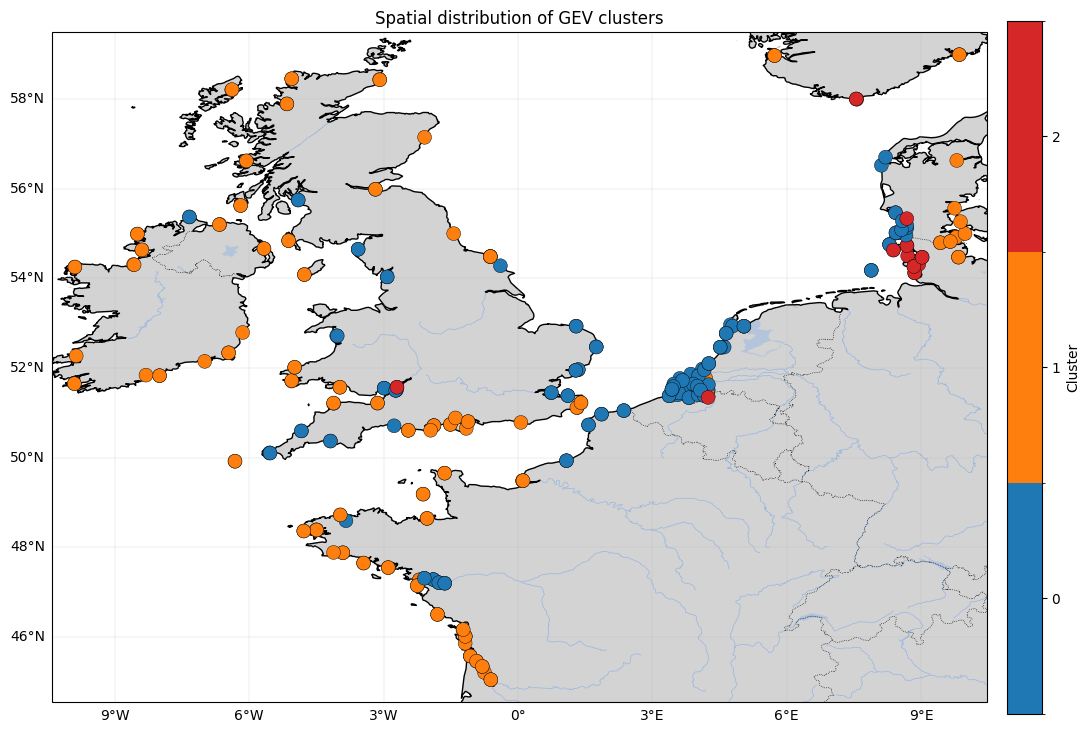

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
from matplotlib.ticker import MaxNLocator

# --- Dataframe with coords + clusters ---
df = GEV_clusters.copy()

# --- Auto-detect coordinate columns ---
candidates = [
    ("lat", "lon"),
    ("latitude", "longitude"),
    ("Latitude", "Longitude"),
    ("LAT", "LON"),
]

lat_col = lon_col = None
for a, b in candidates:
    if a in df.columns and b in df.columns:
        lat_col, lon_col = a, b
        break

if lat_col is None or lon_col is None:
    raise ValueError("No lat/lon columns found. Set lat_col and lon_col manually.")

plot_df = df.dropna(subset=[lat_col, lon_col, "cluster"]).copy()
plot_df["cluster"] = plot_df["cluster"].astype(int)

clusters = np.sort(plot_df["cluster"].unique())
n = len(clusters)



# --- Cartopy map ---
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(11, 9))
ax = plt.axes(projection=proj)

# Set map extent with a small buffer
pad = 0.5
ax.set_extent([
    plot_df[lon_col].min() - pad,
    plot_df[lon_col].max() + pad,
    plot_df[lat_col].min() - pad,
    plot_df[lat_col].max() + pad,
], crs=proj)

# --- Basemap features ---
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="white", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=1.0, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=":", zorder=1)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=0)
ax.add_feature(cfeature.RIVERS, linewidth=0.5, zorder=0)

gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# --- Scatter clusters ---
cmap = plt.get_cmap("tab10" if n <= 20 else "gist_ncar")

# --- Discrete normalization so colors align with integers ---
bounds = np.arange(clusters.min() - 0.5, clusters.max() + 1.5, 1)
norm = mcolors.BoundaryNorm(bounds, ncolors=len(bounds))

# --- Scatter clusters (APPLY norm here) ---
sc = ax.scatter(
    plot_df[lon_col],
    plot_df[lat_col],
    c=plot_df["cluster"],
    cmap=cmap,
    norm=norm,
    s=100,
    edgecolor="k",
    linewidth=0.3,
    transform=proj,
    zorder=3
)

# --- Integer-only discrete colorbar ---
cbar = plt.colorbar(
    sc, ax=ax,
    fraction=0.035, pad=0.02,
    boundaries=bounds, ticks=clusters
)
cbar.set_label("Cluster")
cbar.ax.yaxis.set_major_locator(MaxNLocator(integer=True))


ax.set_title("Spatial distribution of GEV clusters")

plt.tight_layout()
plt.show()



In [6]:
model_df.columns

Index(['station', 'u10__mean', 'u10__std', 'u10__min', 'u10__max',
       'u10__median', 'u10__q05', 'u10__q95', 'u10__count',
       'u10__missing_frac',
       ...
       'residual_is_deviant__missing_frac', 'residual_is_deviant__annmax_mean',
       'residual_is_deviant__annmax_std', 'residual_is_deviant__annmax_min',
       'residual_is_deviant__annmax_max', 'residual_is_deviant__annmean_mean',
       'residual_is_deviant__annmean_std', 'residual_is_deviant__annmean_min',
       'residual_is_deviant__annmean_max', 'cluster'],
      dtype='object', length=257)

In [7]:
# PCA: variance of the features

In [8]:
hallo

NameError: name 'hallo' is not defined

In [12]:
model_df

,station,u10__mean,u10__std,u10__min,u10__max,u10__median,u10__q05,u10__q95,u10__count,u10__missing_frac,...,residual_is_deviant__missing_frac,residual_is_deviant__annmax_mean,residual_is_deviant__annmax_std,residual_is_deviant__annmax_min,residual_is_deviant__annmax_max,residual_is_deviant__annmean_mean,residual_is_deviant__annmean_std,residual_is_deviant__annmean_min,residual_is_deviant__annmean_max,cluster
0,1,1.435309,5.204763,-16.211533,26.093597,1.500458,-6.847014,10.088026,750192,0.0,...,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000,1
1,10,1.033226,4.597254,-15.020645,23.730011,0.919975,-6.038169,8.888404,750192,0.0,...,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000,1
2,102,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,10.497694,750192,0.0,...,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000,1
3,103,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,10.497694,750192,0.0,...,0.0,0.127907,0.333986,0,1,0.008964,0.039935,0.0,0.241667,0
4,104,1.807468,5.515200,-17.559769,22.360794,2.133461,-7.619794,10.497694,750192,0.0,...,0.0,0.069767,0.254755,0,1,0.002223,0.014116,0.0,0.104736,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,93,1.321126,4.322766,-13.039688,18.429459,1.281563,-5.325874,8.531832,750192,0.0,...,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000,0
275,94,1.017265,4.200128,-13.300308,19.863937,0.958878,-5.435812,8.052494,750192,0.0,...,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000,1
276,95,1.408155,5.313808,-16.098816,22.026306,1.785545,-7.461143,9.700240,750192,0.0,...,0.0,0.000000,0.000000,0,0,0.000000,0.000000,0.0,0.000000,1
277,97,1.463534,5.589287,-16.075241,26.132431,1.500534,-7.341267,10.628401,750192,0.0,...,0.0,0.023256,0.150715,0,1,0.000023,0.000175,0.0,0.001598,1


In [11]:
model_df["wind_mag"] = np.sqrt(model_df["u10"]**2 + model_df["v10"]**2)

KeyError: 'u10'

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline


In [ ]:
# Final columns to drop
# Explicit identifier columns
drop_cols = {"station", "cluster"}

# Substrings that indicate leakage / forbidden variables
forbidden_substrings = ( "sea_level", "residual", "missing") # "tide",

# Drop any column containing forbidden substrings (case-insensitive)
forbidden_cols = {
    c for c in model_df.columns
    if any(sub in c.lower() for sub in forbidden_substrings)
}
cols_to_drop = drop_cols | forbidden_cols

# Build feature matrix
X = model_df.drop(columns=[c for c in cols_to_drop if c in model_df.columns])
X = X.fillna(X.median())

y = model_df['cluster']


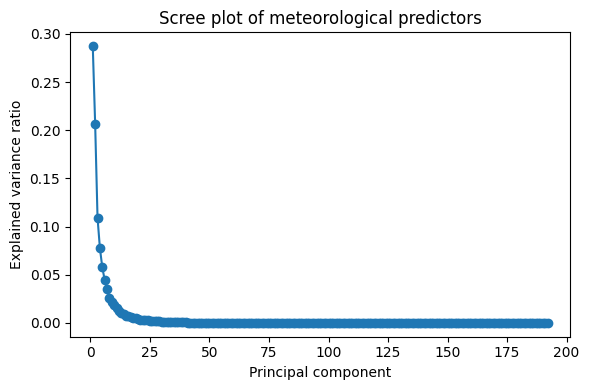

In [ ]:
# PCA: variance of the features
# Standardise
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Scree plot of meteorological predictors")
plt.tight_layout()
plt.show()




In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)
def top_loadings(loadings, pc, n=10):
    return loadings[pc].abs().sort_values(ascending=False).head(n)


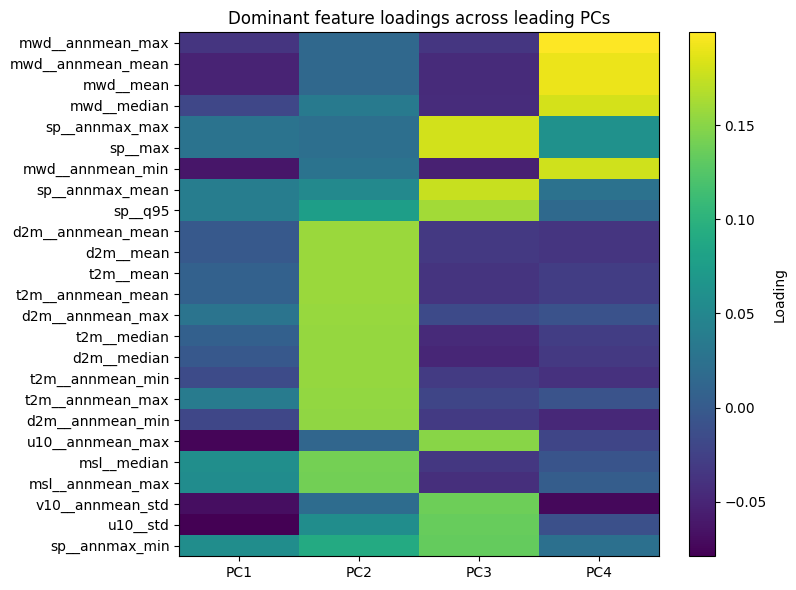

In [ ]:
pcs = ["PC1", "PC2", "PC3", "PC4"]
top_features = (
    loadings[pcs]
    .abs()
    .max(axis=1)
    .sort_values(ascending=False)
    .head(25)
    .index
)

plt.figure(figsize=(8, 6))
plt.imshow(loadings.loc[top_features, pcs], aspect="auto")
plt.colorbar(label="Loading")
plt.yticks(range(len(top_features)), top_features)
plt.xticks(range(len(pcs)), pcs)
plt.title("Dominant feature loadings across leading PCs")
plt.tight_layout()
plt.show()


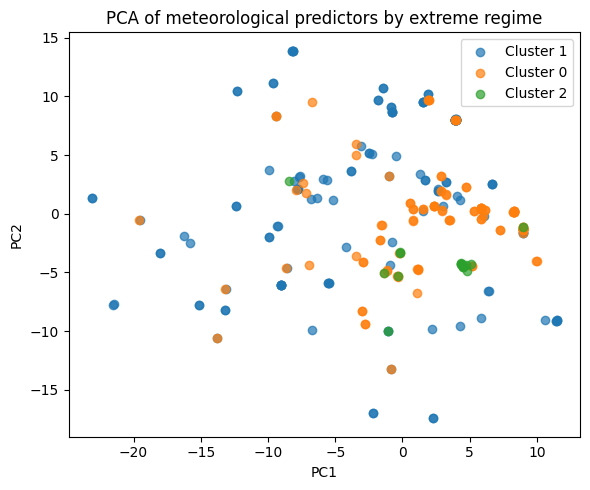

The largest sources of variance in meteorological statistics are not the same as the features that define extreme sea-level regimes.


In [ ]:
pc_df = pd.DataFrame(
    X_pca[:, :2],
    columns=["PC1", "PC2"],
    index=model_df.index
)
pc_df["cluster"] = model_df["cluster"]

plt.figure(figsize=(6, 5))
for c in pc_df["cluster"].unique():
    subset = pc_df[pc_df["cluster"] == c]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {c}", alpha=0.7)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of meteorological predictors by extreme regime")
plt.tight_layout()
plt.show()

print("The largest sources of variance in meteorological statistics are not the same as the features that define extreme sea-level regimes.")


# Reduce variables

Retain only variables that contribute meaningfully to non-trivial PCs.

In [ ]:
loadings_abs = loadings.abs()

# Focus on PCs beyond mean-state (PC3–PC10)
pcs_of_interest = [f"PC{i}" for i in range(1, 11)]

important_features_pca = (
    loadings_abs[pcs_of_interest]
    .max(axis=1)
    .sort_values(ascending=False)
)

# Threshold: keep top X%
pca_keep = important_features_pca[important_features_pca > 0.05].index


In [ ]:
pca_keep.shape

(182,)

In [ ]:
X_screen = X[pca_keep]

In [ ]:
from sklearn.feature_selection import f_classif
import numpy as np

X_screen = X[pca_keep]
X_scaled_screen = StandardScaler().fit_transform(X_screen)

fvals, pvals = f_classif(X_scaled_screen, y)

anova_df = pd.DataFrame({
    "feature": X_screen.columns,
    "F": fvals,
    "pval": pvals
}).sort_values("F", ascending=False)

selected_anova = anova_df[anova_df["pval"] < 0.05]["feature"]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

pipe_l1 = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="saga",
        multi_class="multinomial",
        C=0.1,
        max_iter=2000
    ))
])

pipe_l1.fit(X_screen[selected_anova], y)

coef_l1 = pd.DataFrame(
    pipe_l1.named_steps["clf"].coef_,
    columns=selected_anova,
    index=pipe_l1.named_steps["clf"].classes_
)

final_features = coef_l1.columns[(coef_l1.abs() > 0).any(axis=0)]


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# Final reduced predictor matrix
X_final = model_df[final_features.tolist()]

# Median imputation using ONLY reduced features
X_final = X_final.fillna(X_final.median())

y_final = model_df["cluster"]


In [ ]:
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        multi_class="multinomial",
        solver="lbfgs",
        max_iter=500,
        penalty="l2"
    ))
])
#X_final = X.fillna(X_final.median())

pipe.fit(X_final, y_final )


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 LogisticRegression(max_iter=500, multi_class='multinomial'))])

In [ ]:
coef = pipe.named_steps["clf"].coef_
classes = pipe.named_steps["clf"].classes_

coef_df = pd.DataFrame(
    coef,
    index=classes,
    columns=X_final.columns
)


In [ ]:
coef_df

,t2m__annmean_std,d2m__annmax_std,t2m__min,d2m__max,d2m__annmax_max,sst__min,mwp__min,tp__annmax_min,msl__min,mwd__q95,...,swh__count,mwp__count,msl__max,msl__annmax_max,tp__annmax_std,u10__annmax_std,msl__q95,tide__median,tide__q05,u10__annmean_min
0,0.180584,0.272593,0.230506,-0.388714,-0.388714,-0.408572,-0.177618,-0.292550,-0.182149,0.668614,...,0.201951,0.201951,-0.134608,-0.134608,0.259982,-0.438008,0.338053,-0.371267,-0.262309,-0.078851
1,-0.817901,-0.630221,-0.020137,-0.277269,-0.277269,-0.021521,0.030446,-0.010391,-0.017041,0.166467,...,0.029423,0.029423,0.011079,0.011079,-0.072456,-0.784675,-0.418389,-0.683215,0.600200,-0.024627
2,0.637317,0.357628,-0.210368,0.665983,0.665983,0.430093,0.147172,0.302941,0.199190,-0.835081,...,-0.231374,-0.231374,0.123529,0.123529,-0.187526,1.222683,0.080336,1.054482,-0.337892,0.103478


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(pipe, X_final, y_final, cv=5, scoring="accuracy")
scores.mean(), scores.std()


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-pa

(0.7270779220779222, 0.08201213868827381)

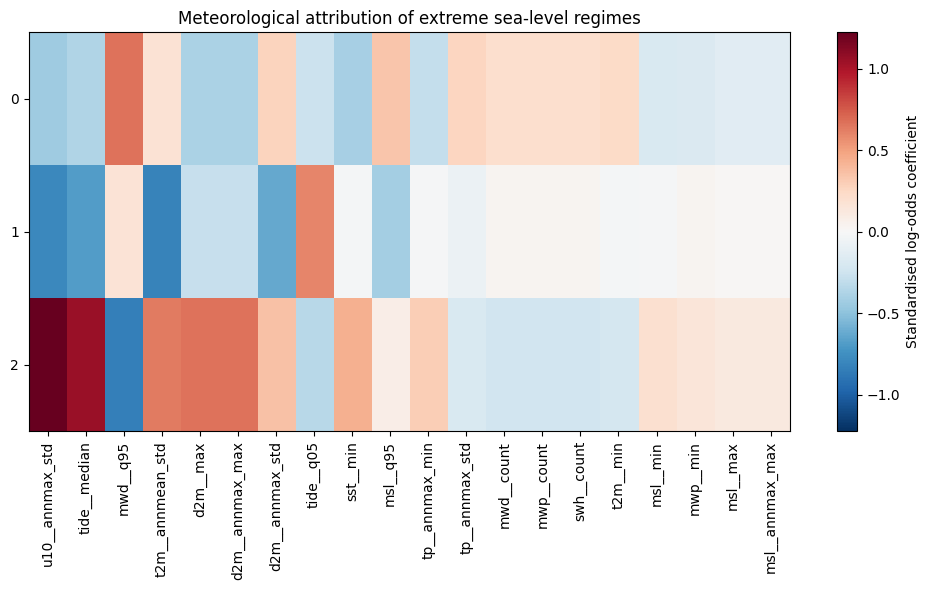

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Select most influential predictors across clusters
abs_mean = coef_df.abs().mean(axis=0)
top_features = abs_mean.sort_values(ascending=False).head(20).index

coef_top = coef_df[top_features]

# --- define symmetric color limits ---
vmax = np.abs(coef_top.values).max()
vmin = -vmax

plt.figure(figsize=(10, 6))

im = plt.imshow(
    coef_top,
    aspect="auto",
    cmap="RdBu_r",   # red–blue, red = positive, blue = negative
    vmin=vmin,
    vmax=vmax
)

cbar = plt.colorbar(im)
cbar.set_label("Standardised log-odds coefficient")

plt.yticks(range(len(coef_top.index)), coef_top.index)
plt.xticks(range(len(top_features)), top_features, rotation=90)

plt.title("Meteorological attribution of extreme sea-level regimes")
plt.tight_layout()
plt.show()


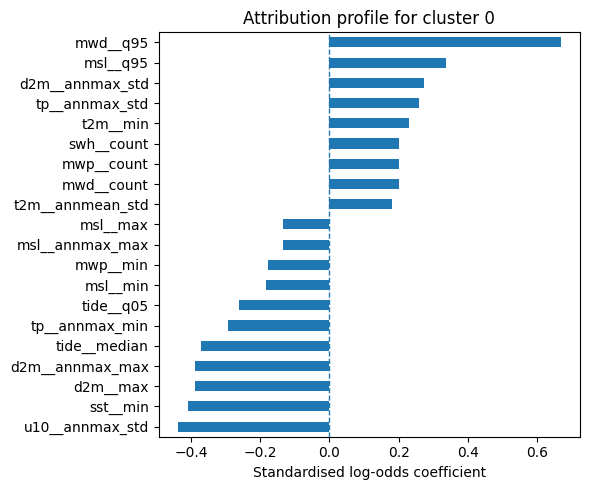

In [ ]:
cluster_id = coef_df.index[0]  # choose cluster of interest

coef_cluster = coef_df.loc[cluster_id, top_features].sort_values()

plt.figure(figsize=(6, 5))
coef_cluster.plot(kind="barh")
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Standardised log-odds coefficient")
plt.title(f"Attribution profile for cluster {cluster_id}")
plt.tight_layout()
plt.show()


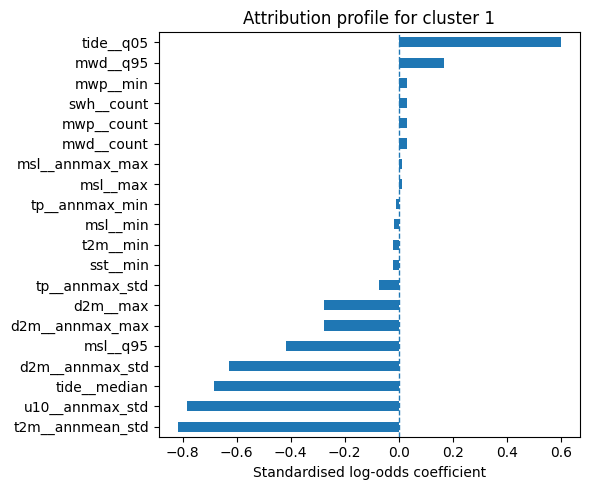

In [ ]:
cluster_id = coef_df.index[1]  # choose cluster of interest

coef_cluster = coef_df.loc[cluster_id, top_features].sort_values()

plt.figure(figsize=(6, 5))
coef_cluster.plot(kind="barh")
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Standardised log-odds coefficient")
plt.title(f"Attribution profile for cluster {cluster_id}")
plt.tight_layout()
plt.show()


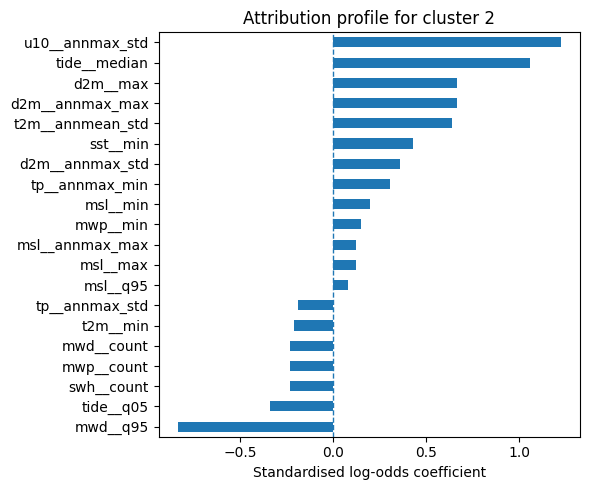

In [ ]:
cluster_id = coef_df.index[2]  # choose cluster of interest

coef_cluster = coef_df.loc[cluster_id, top_features].sort_values()

plt.figure(figsize=(6, 5))
coef_cluster.plot(kind="barh")
plt.axvline(0, linestyle="--", linewidth=1)

plt.xlabel("Standardised log-odds coefficient")
plt.title(f"Attribution profile for cluster {cluster_id}")
plt.tight_layout()
plt.show()


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-pa

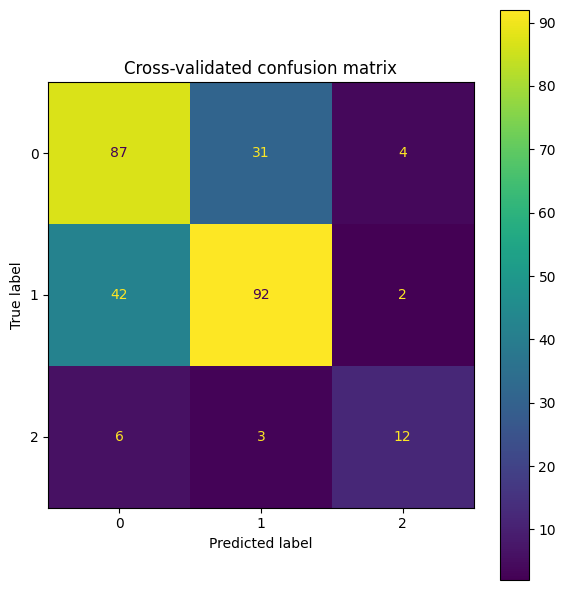

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = cross_val_predict(pipe, X, y, cv=5)

cm = confusion_matrix(y, y_pred, labels=pipe.named_steps["clf"].classes_)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=pipe.named_steps["clf"].classes_
)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax)
ax.set_title("Cross-validated confusion matrix")
plt.tight_layout()
plt.show()


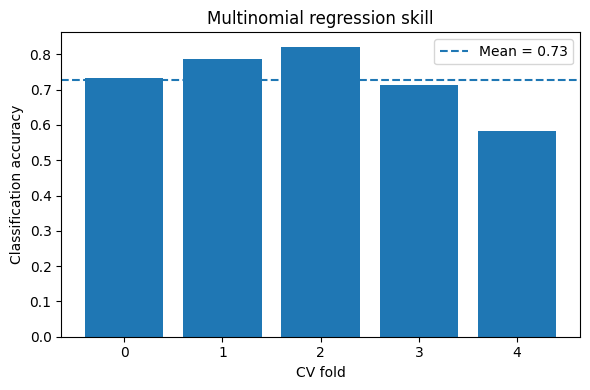

In [ ]:
plt.figure(figsize=(6, 4))
plt.bar(range(len(scores)), scores)
plt.axhline(scores.mean(), linestyle="--", label=f"Mean = {scores.mean():.2f}")

plt.xlabel("CV fold")
plt.ylabel("Classification accuracy")
plt.title("Multinomial regression skill")
plt.legend()
plt.tight_layout()
plt.show()


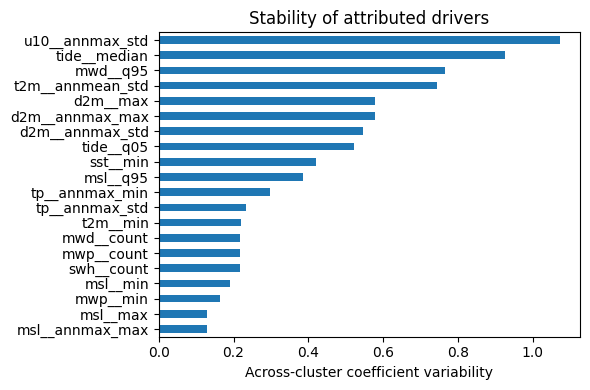

In [ ]:
coef_std = coef_df[top_features].std(axis=0)

plt.figure(figsize=(6, 4))
coef_std.sort_values().plot(kind="barh")
plt.xlabel("Across-cluster coefficient variability")
plt.title("Stability of attributed drivers")
plt.tight_layout()
plt.show()


In [ ]:
print("Original feature count:", X.shape[1])
print("After ANOVA screening:", len(selected_anova))
print("After LASSO selection:", len(final_features))

Original feature count: 192
After ANOVA screening: 140
After LASSO selection: 21


In [ ]:
importance = coef_df.abs().sum(axis=1).sort_values(ascending=False)
importance


2    8.379334
0    5.814152
1    4.962652
dtype: float64

In [ ]:
driver_importance = coef_df.abs().sum(axis=0).sort_values(ascending=False)
driver_importance

u10__annmax_std     2.445366
tide__median        2.108964
mwd__q95            1.670162
t2m__annmean_std    1.635801
d2m__max            1.331965
d2m__annmax_max     1.331965
d2m__annmax_std     1.260442
tide__q05           1.200401
sst__min            0.860186
msl__q95            0.836779
tp__annmax_min      0.605882
tp__annmax_std      0.519964
mwd__count          0.462749
mwp__count          0.462749
swh__count          0.462749
t2m__min            0.461011
msl__min            0.398379
mwp__min            0.355236
msl__max            0.269215
msl__annmax_max     0.269215
u10__annmean_min    0.206957
dtype: float64

In [ ]:
from sklearn.utils import resample
import numpy as np
import pandas as pd

n_boot = 500   # 300–1000 typical for papers
rng = np.random.default_rng(42)

coefs_boot = []

for i in range(n_boot):
    # Resample stations with replacement
    idx = resample(
        np.arange(len(X_final)),
        replace=True,
        n_samples=len(X_final),
        random_state=rng.integers(0, 1e9)
    )

    Xb = X_final.iloc[idx]
    yb = y.iloc[idx]

    pipe.fit(Xb, yb)

    coefs_boot.append(pipe.named_steps["clf"].coef_)

coefs_boot = np.array(coefs_boot)
# shape: (n_boot, n_clusters, n_features)


/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/lb962/miniconda3/envs/telec_env/lib/python3.10/site-pa

In [ ]:
boot_df = pd.DataFrame(
    coefs_boot.reshape(n_boot, -1),
    columns=pd.MultiIndex.from_product(
        [coef_df.index, coef_df.columns],
        names=["cluster", "feature"]
    )
)


In [ ]:
ci_low  = boot_df.quantile(0.025)
ci_high = boot_df.quantile(0.975)
ci_med  = boot_df.quantile(0.50)


In [ ]:
ci_low  = ci_low.unstack(level=0)
ci_high = ci_high.unstack(level=0)
ci_med  = ci_med.unstack(level=0)

In [ ]:
significant = ~((ci_low < 0) & (ci_high > 0))


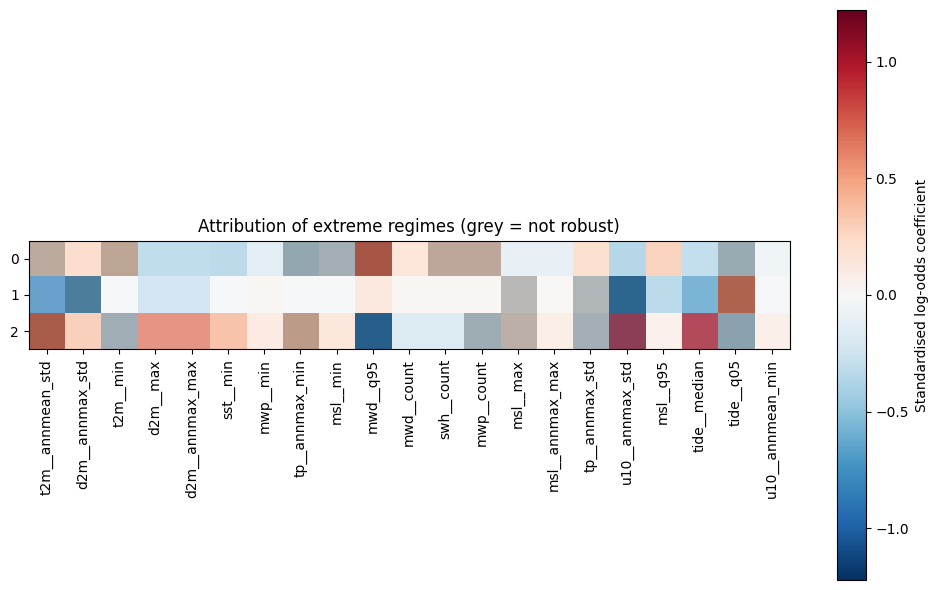

In [ ]:
import matplotlib.pyplot as plt

mask = ~significant.T.values  # True = hide

vmax = np.abs(coef_df.values).max()

plt.figure(figsize=(10, 6))
im = plt.imshow(
    coef_df,
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    aspect="auto"
)

plt.colorbar(im, label="Standardised log-odds coefficient")
plt.yticks(range(len(coef_df.index)), coef_df.index)
plt.xticks(range(len(coef_df.columns)), coef_df.columns, rotation=90)

# Overlay uncertain coefficients
plt.imshow(mask, cmap="gray", alpha=0.25)

plt.title("Attribution of extreme regimes (grey = not robust)")
plt.tight_layout()
plt.show()


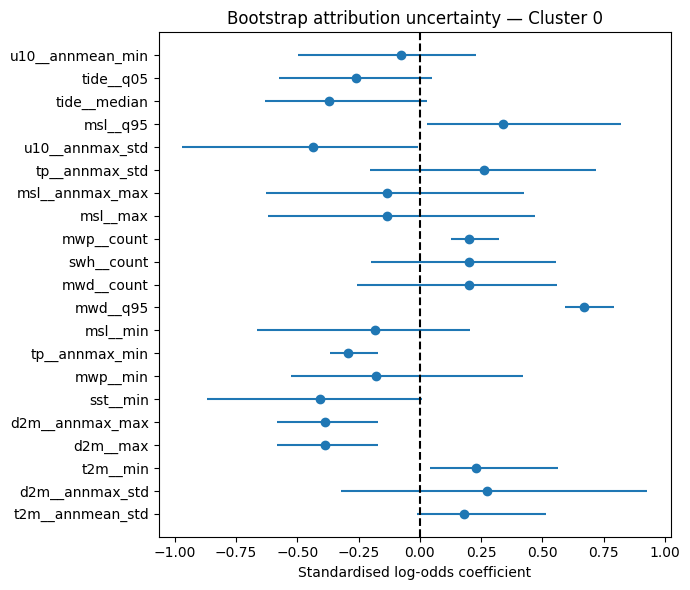

In [ ]:
cluster_id = coef_df.index[0]

mean_vals = coef_df.loc[cluster_id]
err_low = mean_vals - ci_low[cluster_id]
err_high = ci_high[cluster_id] - mean_vals

plt.figure(figsize=(7, 6))
plt.errorbar(
    mean_vals.values,
    mean_vals.index,
    xerr=[err_low.values, err_high.values],
    fmt="o"
)

plt.axvline(0, linestyle="--", color="black")
plt.xlabel("Standardised log-odds coefficient")
plt.title(f"Bootstrap attribution uncertainty — Cluster {cluster_id}")
plt.tight_layout()
plt.show()


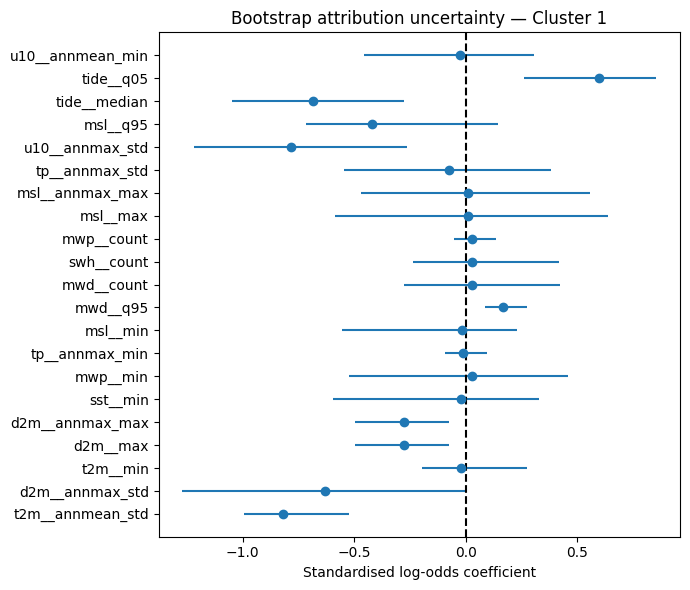

In [ ]:
cluster_id = coef_df.index[1]

mean_vals = coef_df.loc[cluster_id]
err_low = mean_vals - ci_low[cluster_id]
err_high = ci_high[cluster_id] - mean_vals

plt.figure(figsize=(7, 6))
plt.errorbar(
    mean_vals.values,
    mean_vals.index,
    xerr=[err_low.values, err_high.values],
    fmt="o"
)

plt.axvline(0, linestyle="--", color="black")
plt.xlabel("Standardised log-odds coefficient")
plt.title(f"Bootstrap attribution uncertainty — Cluster {cluster_id}")
plt.tight_layout()
plt.show()

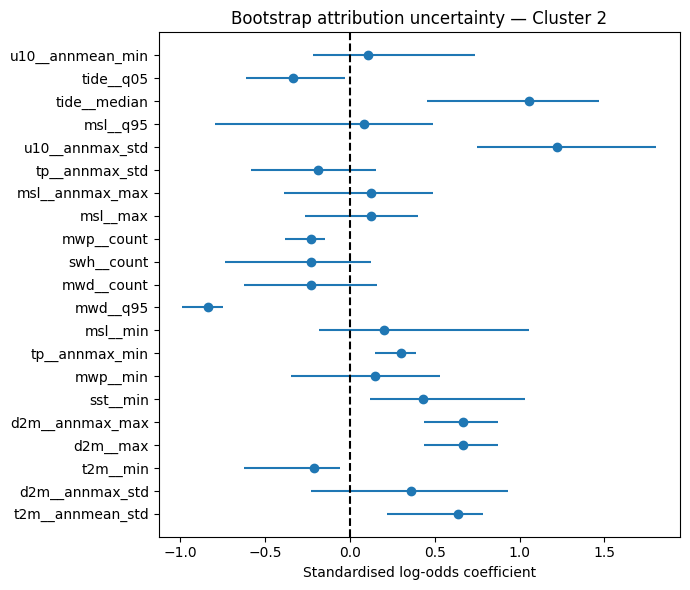

In [ ]:
cluster_id = coef_df.index[2]

mean_vals = coef_df.loc[cluster_id]
err_low = mean_vals - ci_low[cluster_id]
err_high = ci_high[cluster_id] - mean_vals

plt.figure(figsize=(7, 6))
plt.errorbar(
    mean_vals.values,
    mean_vals.index,
    xerr=[err_low.values, err_high.values],
    fmt="o"
)

plt.axvline(0, linestyle="--", color="black")
plt.xlabel("Standardised log-odds coefficient")
plt.title(f"Bootstrap attribution uncertainty — Cluster {cluster_id}")
plt.tight_layout()
plt.show()